In [23]:
import os
import itertools
import importlib
from pathlib import Path
import time
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
import datetime as dt
from cycler import cycler
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
import matplotlib.patches as mpatches
from pdb import set_trace

from gfatpy.lidar.preprocessing import preprocess
from gfatpy.utils.utils import residuals, residuals_2D
from gfatpy.utils.plot import color_list
from gfatpy.lidar.preprocessing.gluing_proportional import gluing
from gfatpy.lidar.preprocessing.lidar_dead_time import estimate_daily_dead_time
from statsmodels.regression.rolling import RollingOLS
from statsmodels.tools import add_constant

%matplotlib inline

%load_ext autoreload

%autoreload 2

In [24]:
crop_range=(0,10000)
bg_threshold_an = 0.1
upper_bg_threshold_pc = 50

channel_an, channel_pc = ('532fta', '532ftp')
min_val = 0
max_val = 60
bin_width = 1
data_dir = Path(r'W:\UGR\alhambra\1a')
tau_dir  = Path(r'W:\UGR\alhambra\QA\dead_time')
files = data_dir.rglob('alh_1a_Prs_rs_xf_20230315.nc')

for file_ in files: 
    estimate_daily_dead_time(file_, tau_dir, savefig = True)

C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\core\fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\core\_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\core\_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\core\_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\core\_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


TypeError: plot_influence_of_dead_time_correction() got an unexpected keyword argument 'range_limits'

In [18]:
crop_range=(0,10000)
bg_threshold_an = 0.1
upper_bg_threshold_pc = 50

channel_an, channel_pc = ('532fta', '532ftp')
min_val = 0
max_val = 60
bin_width = 1
data_dir = Path(r'W:\UGR\alhambra\1a')
tau_dir  = Path(r'W:\UGR\alhambra\QA\dead_time')
files = data_dir.rglob('alh_1a_Prs_rs_xf_20230315.nc')

for file_ in files:    
    lidar = preprocess(file_, apply_dt=False, save_bg=False, save_dc=True,apply_bz= False, crop_ranges=crop_range)    
    z = lidar.range.values
    time_ = lidar.time.values[0]
    datetime = time_.astype(str).split('T')[0].replace('-','')    
    optimal_taus = {}
    for channel_ in lidar.channel.values:
        if 'a' in channel_:
            channel_an = channel_
            channel_pc = channel_.replace('a','p')
            if channel_pc in lidar.channel:
                optimal_taus[channel_pc] = np.nan
                print(channel_an, channel_pc)    

                signal_an = lidar[f'signal_{channel_an}']
                signal_pc = lidar[f'signal_{channel_pc}'].sel(range=slice(*crop_range))
                set_trace()
                bg_pc = lidar[f'signal_{channel_pc}'].sel(range=slice(50000,60000)).mean('range').values
                bg_threshold_pc = bg_pc + 0.5

                fig,ax = plt.subplots(figsize=[15,5])
                lan = signal_an.plot.line(x='range',c='grey',lw=0.5, label='an')
                lpc = signal_pc.plot.line(x='range',c='black',lw=0.5, label='pc')    
                ax.set_title(datetime)
                ax.set_yscale('log')
                ax.set_ylim(0.01,3000)
                ax.set_xlim(0,10000)

                l1 = plt.hlines(upper_bg_threshold_pc, xmin=0,xmax=10000, color='darkred', ls='--', label='Cmax')
                l2 = plt.hlines(bg_threshold_pc, xmin=0,xmax=10000, color='darkgreen', ls='--', label='bg_threshold')
                l3 = plt.hlines(bg_threshold_an, xmin=0,xmax=10000, color='violet', ls='--', label='bg_threshold_an')    
                ax.legend(handles = [lan[0],lpc[0], l1, l2, l3], fontsize=10, loc='upper right')
                plt.savefig(f'gluing_thresholds_{channel_pc}_{datetime}.png')
                plt.close(fig)

                # Apply gluing condition
                gl_condition = np.logical_and(signal_an.values>bg_threshold_an,signal_pc.values<upper_bg_threshold_pc)
                an = np.concatenate(signal_an.where(gl_condition).values, axis=0)
                pc = np.concatenate(signal_pc.where(gl_condition).values, axis=0)
                isnan = np.logical_and(np.isnan(an), np.isnan(pc))
                an = an[~isnan]
                pc = pc[~isnan]    

                fig,ax = plt.subplots(figsize=[15,5])
                ax.scatter(pc,an, label='raw')
                ax.set_yscale('linear')
                # ax.set_ylim(0.1,60)
                #     ax.set_xlim(0,60)
                ax.legend(fontsize=10, loc='upper right')

                # Assuming signal_pc and signal_an are 1D arrays
                idx_condition = np.logical_and(pc >= min_val, pc < max_val)
                bins = np.arange(min_val, max_val + bin_width, bin_width)

                # Use numpy.digitize to get the bin indices for each element in signal_pc
                bin_indices = np.digitize(pc, bins)

                # Use numpy.bincount to count the number of occurrences in each bin
                bin_counts = np.bincount(bin_indices)

                # Compute the median, mean, and standard deviation for each bin
                median_pc = np.array([np.median(pc[bin_indices == i]) for i in range(1, len(bins))])
                mean_an = np.array([np.mean(an[bin_indices == i]) for i in range(1, len(bins))])
                std_an = np.array([np.std(an[bin_indices == i]) for i in range(1, len(bins))])
                isnan = np.logical_and(np.isnan(median_pc), np.isnan(mean_an), np.isnan(std_an))
                median_pc = median_pc[~isnan]
                mean_an = mean_an[~isnan]    
                std_an = std_an[~isnan]

                ax.errorbar(median_pc, mean_an, yerr=std_an,  linestyle='None', marker='.', color='red', label='binning')
                ax.set_xlabel('PC signal, [MHz]')
                ax.set_ylabel('dc-corrected AN signal, [mV]')
                ax.set_title(datetime)    
                ax.legend(fontsize=10, loc='upper left')
                plt.savefig(f'an_pc_{channel_pc}_{datetime}.png')
                ax.grid(True, which='both', linestyle=':', linewidth=0.5, color=[0.3,0.3,0.3])
                plt.close(fig)

                #Tau correction
                tau_range = np.arange(2,10,1)
                fig,ax = plt.subplots(figsize=[15,5])
                ax.scatter(mean_an,median_pc, label='original')
                colors = color_list(len(tau_range))
                for idx, tau_ in enumerate(tau_range):    
                    dt_pc = median_pc/(1-tau_*median_pc*1e-3)
                    ax.scatter(mean_an,dt_pc, color=colors[idx], label=f'tau={tau_} ns')
                ax.legend(fontsize=10, loc='upper left')
                ax.set_ylabel('dt-corrected PC signal, [MHz]')
                ax.set_xlabel('dc-corrected AN signal, [mV]')
                ax.set_title(datetime)    
                ax.grid(True, which='both', linestyle=':', linewidth=0.5, color=[0.3,0.3,0.3])
                plt.savefig(f'pc_taus_{channel_pc}_{datetime}.png')
                plt.close(fig)

                #Virtual analog
                tau_range = np.arange(1,10,0.1)
                J = np.nan*np.ones(len(tau_range))
                for idx, tau_ in enumerate(tau_range):    
                    dt_pc = median_pc/(1-tau_*median_pc*1e-3)
                    if not np.isnan(dt_pc).any() and not np.isnan(mean_an).any():
                        try:
                            fit_values = np.polyfit(dt_pc, mean_an, 1)
                            virtual_an = np.polyval(fit_values,dt_pc)

                            #Cost function
                            idx_zero = std_an == 0
                            J[idx] = np.sum((mean_an[~idx_zero] - virtual_an[~idx_zero])**2/std_an[~idx_zero]**2)/len(an)
                            
                            logJ = np.log(J)
                            optimal_taus[channel_pc] = tau_range[logJ.argmin()]                             

                            fig,ax = plt.subplots(figsize=[15,5])
                            ax.plot(tau_range,logJ, c='blue', lw=2, label='J',zorder=1)
                            ax.scatter(optimal_taus[channel_pc], logJ[logJ.argmin()], marker='p',s=50,color='yellow', label=f'optimal tau = {optimal_taus[channel_pc]:.2f} ns',zorder=2)
                            ax.set_ylabel('log(J), [#]')
                            ax.set_xlabel(r'$\tau$, [ns]')
                            ax.minorticks_on()
                            ax.grid(True, which='both', linestyle=':', linewidth=0.5, color=[0.3,0.3,0.3])
                            ax.set_title(datetime)
                            ax.legend(fontsize=10, loc='upper center')
                            plt.savefig(f'cost_function_{channel_pc}_{datetime}.png')
                            plt.close(fig)                            
                        except:
                            continue                            
    
    # Create DataArray
    tau_da = xr.DataArray(list(optimal_taus.values()), coords=[list(optimal_taus.keys())], dims=['channel'])
    tau_da.attrs['date'] = datetime
    tau_da.to_netcdf(tau_dir / f'alh_dead-time_{datetime}.nc')
                            

532nsa 532nsp
> c:\users\usuario\appdata\local\temp\ipykernel_9920\438530138.py(30)<module>()

ipdb> signal_pc
<xarray.DataArray 'signal_532nsp' (time: 719, range: 2666)>
dask.array<getitem, shape=(719, 2666), dtype=float64, chunksize=(719, 2666), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2023-03-15T18:51:04 ... 2023-03-16T07:03:36
  * range    (range) float32 3.75 7.5 11.25 ... 9.99e+03 9.994e+03 9.998e+03
ipdb> signal_pc.name
'signal_532nsp'
ipdb> signal_pc.name.split('_')[-1]
'532nsp'
ipdb> q


In [ ]:
def estimate_daily_dead_time(file, tau_dir, crop_range=(0,15000)):
    
    #Management file type
    
    
    #Read
    lidar = preprocess(file_, apply_dt=False, save_bg=False, save_dc=True,apply_bz= False, crop_ranges=crop_range)
    
    

In [ ]:
crop_range=(0,10000)
bg_threshold_an = 0.1
upper_bg_threshold_pc = 50

channel_an, channel_pc = ('532fta', '532ftp')
min_val = 0
max_val = 60
bin_width = 1
data_dir = Path(r'W:\UGR\alhambra\1a')
tau_dir  = Path(r'W:\UGR\alhambra\QA\dead_time')
files = data_dir.rglob('alh_1a_Prs_rs_xf_20230315.nc')

for file_ in files:    
    lidar = preprocess(file_, apply_dt=False, save_bg=False, save_dc=True,apply_bz= False, crop_ranges=crop_range)    
    z = lidar.range.values
    time_ = lidar.time.values[0]
    datetime = time_.astype(str).split('T')[0].replace('-','')    
    optimal_taus = {}
    for channel_ in lidar.channel.values:
        if 'a' in channel_:
            channel_an = channel_
            channel_pc = channel_.replace('a','p')
            if channel_pc in lidar.channel:
                optimal_taus[channel_pc] = np.nan
                print(channel_an, channel_pc)    

                signal_an = lidar[f'signal_{channel_an}']
                signal_pc = lidar[f'signal_{channel_pc}'].sel(range=slice(*crop_range))
                bg_pc = lidar[f'signal_{channel_pc}'].sel(range=slice(50000,60000)).mean('range').values
                bg_threshold_pc = bg_pc + 0.5

                fig,ax = plt.subplots(figsize=[15,5])
                lan = signal_an.plot.line(x='range',c='grey',lw=0.5, label='an')
                lpc = signal_pc.plot.line(x='range',c='black',lw=0.5, label='pc')    
                ax.set_title(datetime)
                ax.set_yscale('log')
                ax.set_ylim(0.01,3000)
                ax.set_xlim(0,10000)

                l1 = plt.hlines(upper_bg_threshold_pc, xmin=0,xmax=10000, color='darkred', ls='--', label='Cmax')
                l2 = plt.hlines(bg_threshold_pc, xmin=0,xmax=10000, color='darkgreen', ls='--', label='bg_threshold')
                l3 = plt.hlines(bg_threshold_an, xmin=0,xmax=10000, color='violet', ls='--', label='bg_threshold_an')    
                ax.legend(handles = [lan[0],lpc[0], l1, l2, l3], fontsize=10, loc='upper right')
                plt.savefig(f'gluing_thresholds_{channel_pc}_{datetime}.png')
                plt.close(fig)

                # Apply gluing condition
                gl_condition = np.logical_and(signal_an.values>bg_threshold_an,signal_pc.values<upper_bg_threshold_pc)
                an = np.concatenate(signal_an.where(gl_condition).values, axis=0)
                pc = np.concatenate(signal_pc.where(gl_condition).values, axis=0)
                isnan = np.logical_and(np.isnan(an), np.isnan(pc))
                an = an[~isnan]
                pc = pc[~isnan]    

                fig,ax = plt.subplots(figsize=[15,5])
                ax.scatter(pc,an, label='raw')
                ax.set_yscale('linear')
                # ax.set_ylim(0.1,60)
                #     ax.set_xlim(0,60)
                ax.legend(fontsize=10, loc='upper right')

                # Assuming signal_pc and signal_an are 1D arrays
                idx_condition = np.logical_and(pc >= min_val, pc < max_val)
                bins = np.arange(min_val, max_val + bin_width, bin_width)

                # Use numpy.digitize to get the bin indices for each element in signal_pc
                bin_indices = np.digitize(pc, bins)

                # Use numpy.bincount to count the number of occurrences in each bin
                bin_counts = np.bincount(bin_indices)

                # Compute the median, mean, and standard deviation for each bin
                median_pc = np.array([np.median(pc[bin_indices == i]) for i in range(1, len(bins))])
                mean_an = np.array([np.mean(an[bin_indices == i]) for i in range(1, len(bins))])
                std_an = np.array([np.std(an[bin_indices == i]) for i in range(1, len(bins))])
                isnan = np.logical_and(np.isnan(median_pc), np.isnan(mean_an), np.isnan(std_an))
                median_pc = median_pc[~isnan]
                mean_an = mean_an[~isnan]    
                std_an = std_an[~isnan]

                ax.errorbar(median_pc, mean_an, yerr=std_an,  linestyle='None', marker='.', color='red', label='binning')
                ax.set_xlabel('PC signal, [MHz]')
                ax.set_ylabel('dc-corrected AN signal, [mV]')
                ax.set_title(datetime)    
                ax.legend(fontsize=10, loc='upper left')
                plt.savefig(f'an_pc_{channel_pc}_{datetime}.png')
                ax.grid(True, which='both', linestyle=':', linewidth=0.5, color=[0.3,0.3,0.3])
                plt.close(fig)

                #Tau correction
                tau_range = np.arange(2,10,1)
                fig,ax = plt.subplots(figsize=[15,5])
                ax.scatter(mean_an,median_pc, label='original')
                colors = color_list(len(tau_range))
                for idx, tau_ in enumerate(tau_range):    
                    dt_pc = median_pc/(1-tau_*median_pc*1e-3)
                    ax.scatter(mean_an,dt_pc, color=colors[idx], label=f'tau={tau_} ns')
                ax.legend(fontsize=10, loc='upper left')
                ax.set_ylabel('dt-corrected PC signal, [MHz]')
                ax.set_xlabel('dc-corrected AN signal, [mV]')
                ax.set_title(datetime)    
                ax.grid(True, which='both', linestyle=':', linewidth=0.5, color=[0.3,0.3,0.3])
                plt.savefig(f'pc_taus_{channel_pc}_{datetime}.png')
                plt.close(fig)

                #Virtual analog
                tau_range = np.arange(1,10,0.1)
                J = np.nan*np.ones(len(tau_range))
                for idx, tau_ in enumerate(tau_range):    
                    dt_pc = median_pc/(1-tau_*median_pc*1e-3)
                    if not np.isnan(dt_pc).any() and not np.isnan(mean_an).any():
                        try:
                            fit_values = np.polyfit(dt_pc, mean_an, 1)
                            virtual_an = np.polyval(fit_values,dt_pc)

                            #Cost function
                            idx_zero = std_an == 0
                            J[idx] = np.sum((mean_an[~idx_zero] - virtual_an[~idx_zero])**2/std_an[~idx_zero]**2)/len(an)
                            
                            logJ = np.log(J)
                            optimal_taus[channel_pc] = tau_range[logJ.argmin()]                             

                            fig,ax = plt.subplots(figsize=[15,5])
                            ax.plot(tau_range,logJ, c='blue', lw=2, label='J',zorder=1)
                            ax.scatter(optimal_taus[channel_pc], logJ[logJ.argmin()], marker='p',s=50,color='yellow', label=f'optimal tau = {optimal_taus[channel_pc]:.2f} ns',zorder=2)
                            ax.set_ylabel('log(J), [#]')
                            ax.set_xlabel(r'$\tau$, [ns]')
                            ax.minorticks_on()
                            ax.grid(True, which='both', linestyle=':', linewidth=0.5, color=[0.3,0.3,0.3])
                            ax.set_title(datetime)
                            ax.legend(fontsize=10, loc='upper center')
                            plt.savefig(f'cost_function_{channel_pc}_{datetime}.png')
                            plt.close(fig)                            
                        except:
                            continue                            
    
    # Create DataArray
    tau_da = xr.DataArray(list(optimal_taus.values()), coords=[list(optimal_taus.keys())], dims=['channel'])
    tau_da.attrs['date'] = datetime
    tau_da.to_netcdf(tau_dir / f'alh_dead-time_{datetime}.nc')
                            

In [16]:
signal_an = lidar.signal_532fta

NameError: name 'lidar' is not defined

In [4]:
def moving_linear_fit(x: np.ndarray, y: np.ndarray, w: int, get_intercept: bool = True) -> tuple:
    """
    Perform moving linear regression between two arrays x and y.

    Parameters:
        x (np.ndarray): The independent variable array with shape (n,).
        y (np.ndarray): The dependent variable array with shape (n,).
        w (int): The window size for the rolling regression.
        get_intercept (bool): Whether to include the intercept in the regression. Default is True.

    Returns:
        tuple: A tuple containing the slope (np.ndarray) and intercept (np.ndarray or None if get_intercept=False), and r squared.
    """
    intercept = None
    if get_intercept:
        y_ = add_constant(y)
    else:
        y_ = y
    rols = RollingOLS(x, y_, window=w, expanding=True)
    rres = rols.fit()
    params = rres.params
    rsquared = rres.rsquared
    if params.shape[1] == 1:
        slope = np.squeeze(params)
    else:
        intercept = params[:, 0]
        slope = params[:, 1]        
            
    return slope, intercept, rsquared

def moving_linear_fit_2D(x: np.ndarray, y: np.ndarray, w: int, get_intercept: bool = True) -> tuple:
    """
    Perform moving linear regression between a 1D array x and a 2D array y.

    Parameters:
        x (np.ndarray): The independent variable array with shape (n,).
        y (np.ndarray): The dependent variable array with shape (p, n).
        w (int): The window size for the rolling regression.
        get_intercept (bool): Whether to include the intercept in the regression. Default is True.

    Returns:
        tuple: A tuple containing the slopes (np.ndarray) and intercepts (np.ndarray or None if get_intercept=False), and R-squared values.
    """
    p, n = y.shape

    slopes = np.empty((p,n))
    intercepts = np.empty((p,n))
    rsquared_values = np.empty((p,n))
    for i in range(p):
        y_i = y[i, :]
        slope_i, intercept_i, rsquared_i = moving_linear_fit(x, y_i, w, get_intercept)
        slopes[i,:] = slope_i
        intercepts[i,:] = intercept_i
        rsquared_values[i,:] = rsquared_i

    return slopes, intercepts, rsquared_values


def compute_corrected_array(signal_pc, tau_range):
    tau_range = tau_range[:, np.newaxis]  # Add a new axis to tau_range for broadcasting
    corrected_array = signal_pc.values / (1 - signal_pc.values * tau_range * 1e-3)
    return corrected_array


C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\matplotlib\axes\_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\core\fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\core\_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\core\_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numpy\core\_methods.py

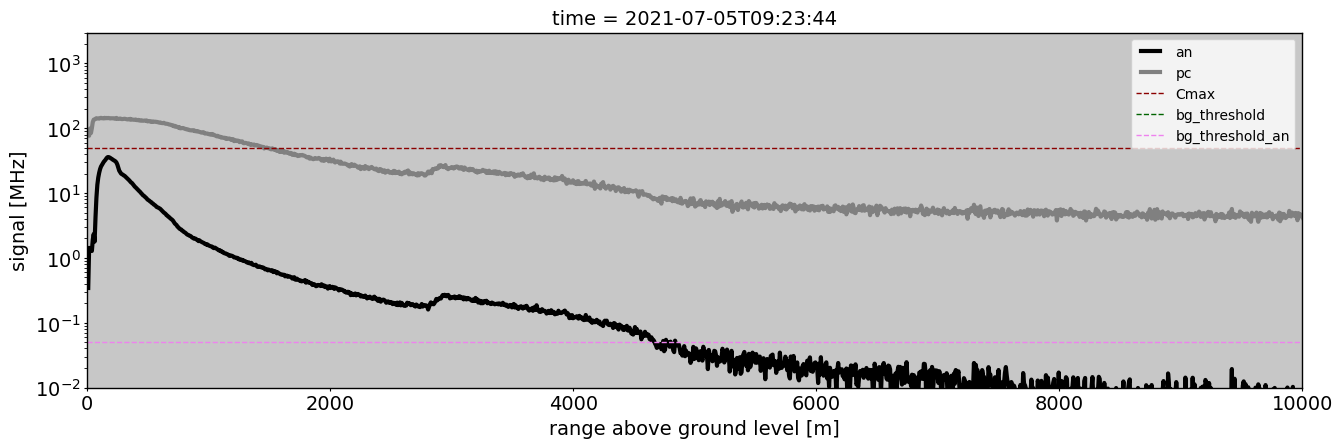

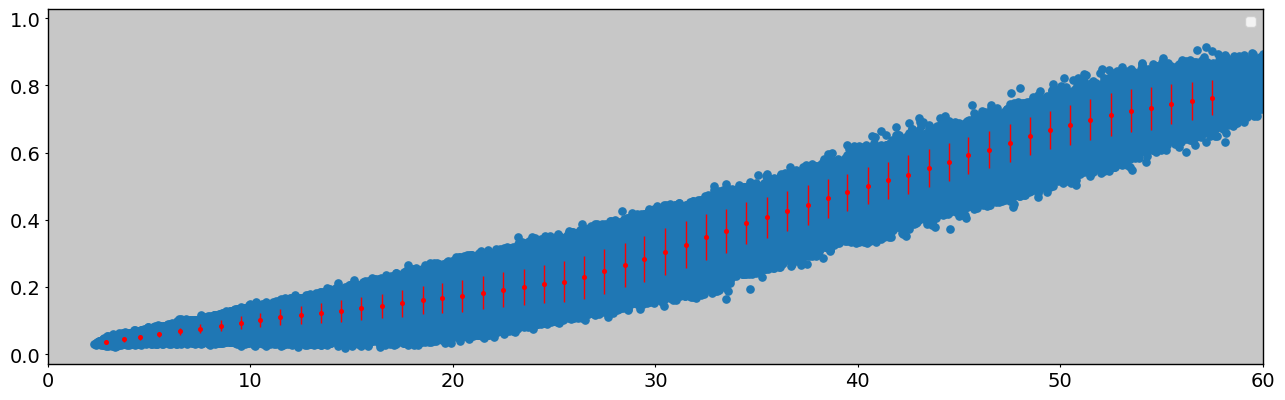

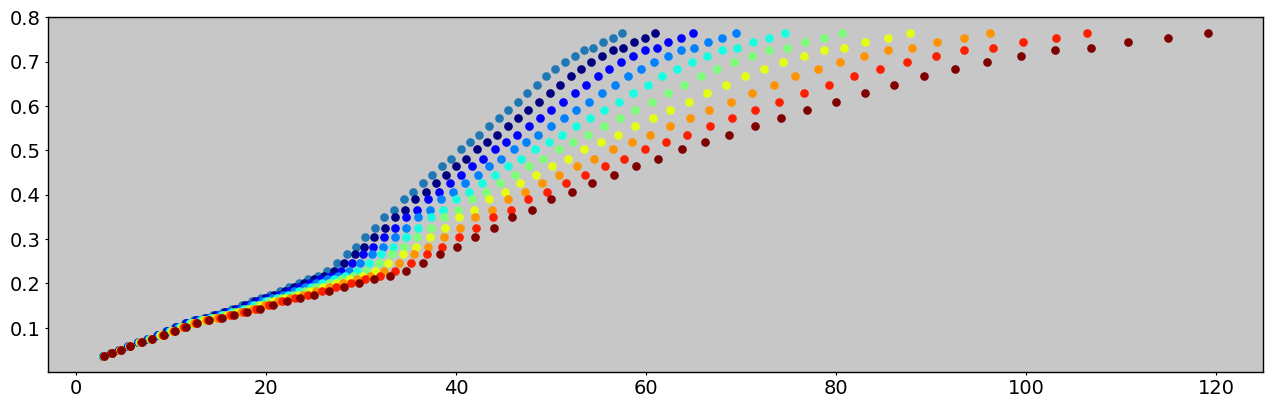

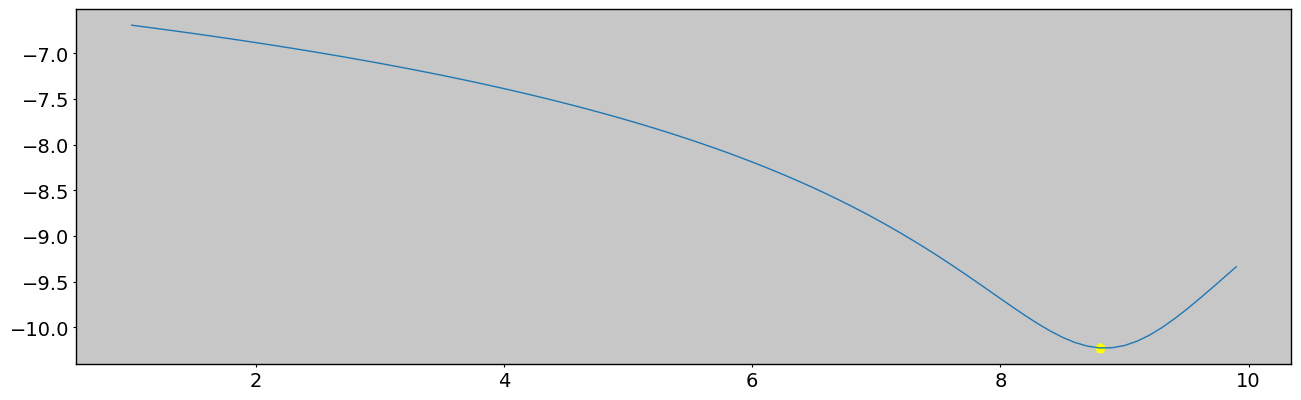

In [69]:
channel_an, channel_pc = '532xpa', '532xpp'
time_ = "2021-07-05T09:23:44.000000000"
datetime = time_.split('.')[0].replace('-','').replace(':','')

signal_an = dc_lidar[f'signal_{channel_an}'].sel(time=time_)
signal_pc = lidar[f'signal_{channel_pc}'].sel(time=time_)
bg_pc = signal_pc.sel(range=slice(50000,60000)).mean('range').values
bg_threshold_pc = bg_pc + 0.5
bg_threshold_an = 0.05
upper_bg_threshold_pc = 50

fig,ax = plt.subplots(figsize=[15,5])
signal_an.plot(ax=ax, lw=3, c='k', label='an')
signal_pc.plot(ax=ax, lw=3, c='grey', label='pc')
ax.set_yscale('log')
ax.set_ylim(0.01,3000)
ax.set_xlim(0,10000)

plt.hlines(upper_bg_threshold_pc, xmin=0,xmax=10000, color='darkred', ls='--', label='Cmax')
plt.hlines(bg_threshold_pc, xmin=0,xmax=10000, color='darkgreen', ls='--', label='bg_threshold')
plt.hlines(bg_threshold_an, xmin=0,xmax=10000, color='violet', ls='--', label='bg_threshold_an')
ax.legend(fontsize=10, loc='upper right')
plt.savefig(f'pc_candidates_{channel_pc}_{datetime}.png')

# Apply gluing condition
gl_condition = np.logical_and(signal_an>bg_threshold_an,signal_pc<upper_bg_threshold_pc)
an = np.concatenate(dc_lidar[f'signal_{channel_an}'].where(gl_condition).dropna('range').values, axis=0)
pc = np.concatenate(lidar[f'signal_{channel_pc}'].where(gl_condition).dropna('range').values, axis=0)
n
fig,ax = plt.subplots(figsize=[15,5])
ax.scatter(pc,an)
ax.set_yscale('linear')
# ax.set_ylim(0.1,60)
ax.set_xlim(0,60)
ax.legend(fontsize=10, loc='upper right')

min_val = 0
max_val = 60
bin_width = 1

# Assuming signal_pc and signal_an are 1D arrays
idx_condition = np.logical_and(pc >= min_val, pc < max_val)
bins = np.arange(min_val, max_val + bin_width, bin_width)

# Use numpy.digitize to get the bin indices for each element in signal_pc
bin_indices = np.digitize(pc, bins)

# Use numpy.bincount to count the number of occurrences in each bin
bin_counts = np.bincount(bin_indices)

# Compute the median, mean, and standard deviation for each bin
median_pc = np.array([np.median(pc[bin_indices == i]) for i in range(1, len(bins))])
mean_an = np.array([np.mean(an[bin_indices == i]) for i in range(1, len(bins))])
std_an = np.array([np.std(an[bin_indices == i]) for i in range(1, len(bins))])
median_pc = median_pc[:-2]
mean_an = mean_an[:-2]
std_an = std_an[:-2]

ax.errorbar(median_pc, mean_an, yerr=std_an,  linestyle='None', marker='.', color='red')


tau_range = np.arange(1,10,1)
fig,ax = plt.subplots(figsize=[15,5])
ax.scatter(median_pc,mean_an)
colors = color_list(len(tau_range))
for idx, tau_ in enumerate(tau_range):
    dt_pc = median_pc/(1-tau_*median_pc*1e-3)
    ax.scatter(dt_pc,mean_an, color=colors[idx])
    
    
#Virtual analog
idx_nan = np.logical_and(np.isnan(median_pc), np.isnan(mean_an), np.isnan(median_pc))
median_pc = median_pc[~idx_nan]
mean_an = mean_an[~idx_nan]
std_an = std_an[~idx_nan]
tau_range = np.arange(1,10,0.1)
J = np.nan*np.ones(len(tau_range))
for idx, tau_ in enumerate(tau_range):    
    dt_pc = median_pc/(1-tau_*median_pc*1e-3)
    if not np.isnan(dt_pc).any() and not np.isnan(mean_an).any():        
        fit_values = np.polyfit(dt_pc, mean_an, 1)
        virtual_an = np.polyval(fit_values,dt_pc)

        #Cost function
        idx_zero = std_an == 0
        J[idx] = np.sum((mean_an[~idx_zero] - virtual_an[~idx_zero])**2/std_an[~idx_zero]**2)/len(an)

logJ = np.log(J)
optimal_tau = tau_range[logJ.argmin()]

fig,ax = plt.subplots(figsize=[15,5])
ax.plot(tau_range,logJ)
ax.scatter(optimal_tau, logJ[logJ.argmin()], marker='p',s=50,color='yellow')



C:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\matplotlib\axes\_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


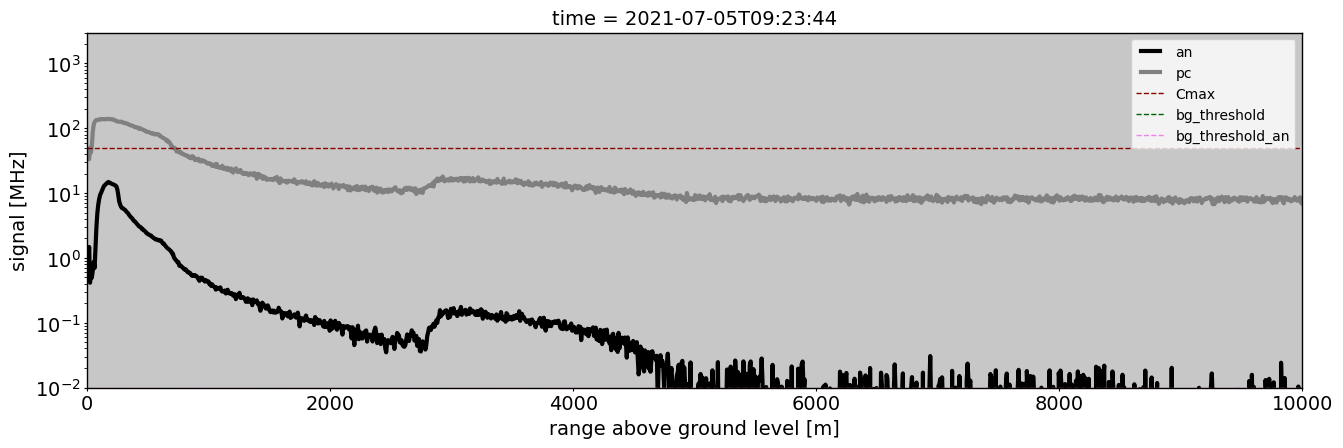

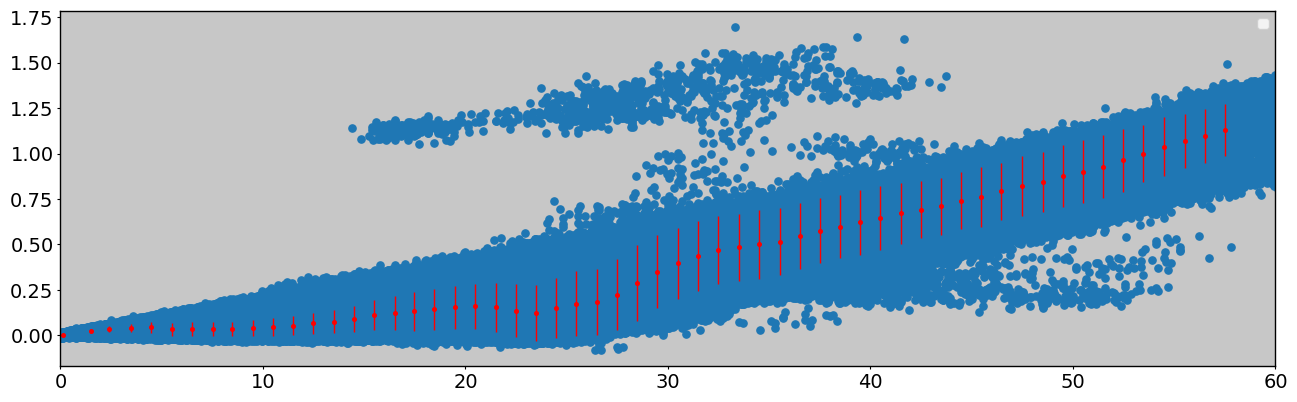

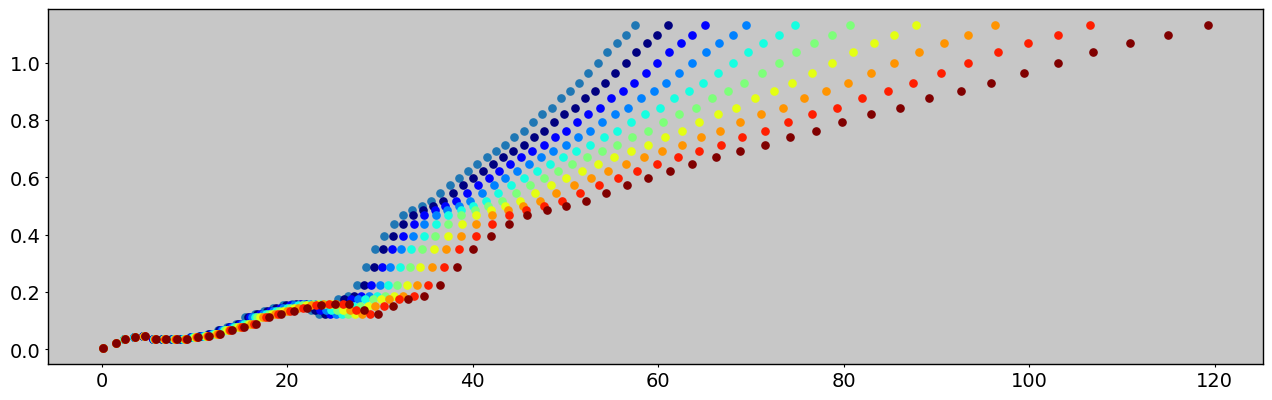

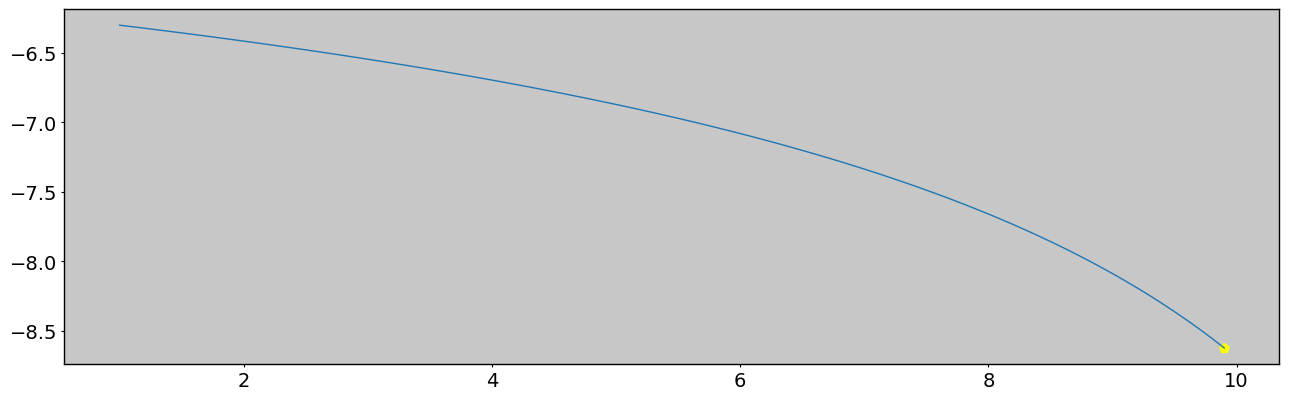

In [71]:
channel_an, channel_pc = '532xsa', '532xsp'
datetime = time_.split('.')[0].replace('-','').replace(':','')

#TODO pintar todos los perfiles!!!!!
signal_an = dc_lidar[f'signal_{channel_an}'].sel(time=time_)
signal_pc = lidar[f'signal_{channel_pc}'].sel(time=time_)
bg_pc = signal_pc.sel(range=slice(50000,60000)).mean('range').values
bg_threshold_pc = bg_pc + 0.5
bg_threshold_an = 0.01
upper_bg_threshold_pc = 50

fig,ax = plt.subplots(figsize=[15,5])
signal_an.plot(ax=ax, lw=3, c='k', label='an')
signal_pc.plot(ax=ax, lw=3, c='grey', label='pc')
ax.set_yscale('log')
ax.set_ylim(0.01,3000)
ax.set_xlim(0,10000)

plt.hlines(upper_bg_threshold_pc, xmin=0,xmax=10000, color='darkred', ls='--', label='Cmax')
plt.hlines(bg_threshold_pc, xmin=0,xmax=10000, color='darkgreen', ls='--', label='bg_threshold')
plt.hlines(bg_threshold_an, xmin=0,xmax=10000, color='violet', ls='--', label='bg_threshold_an')
ax.legend(fontsize=10, loc='upper right')
plt.savefig(f'pc_candidates_{channel_pc}_{datetime}.png')

# Apply gluing condition
gl_condition = np.logical_and(signal_an>bg_threshold_an,signal_pc<upper_bg_threshold_pc)
an = np.concatenate(dc_lidar[f'signal_{channel_an}'].where(gl_condition).dropna('range').values, axis=0)
pc = np.concatenate(lidar[f'signal_{channel_pc}'].where(gl_condition).dropna('range').values, axis=0)

fig,ax = plt.subplots(figsize=[15,5])
ax.scatter(pc,an)
ax.set_yscale('linear')
# ax.set_ylim(0.1,60)
ax.set_xlim(0,60)
ax.legend(fontsize=10, loc='upper right')

min_val = 0
max_val = 60
bin_width = 1

# Assuming signal_pc and signal_an are 1D arrays
idx_condition = np.logical_and(pc >= min_val, pc < max_val)
bins = np.arange(min_val, max_val + bin_width, bin_width)

# Use numpy.digitize to get the bin indices for each element in signal_pc
bin_indices = np.digitize(pc, bins)

# Use numpy.bincount to count the number of occurrences in each bin
bin_counts = np.bincount(bin_indices)

# Compute the median, mean, and standard deviation for each bin
median_pc = np.array([np.median(pc[bin_indices == i]) for i in range(1, len(bins))])
mean_an = np.array([np.mean(an[bin_indices == i]) for i in range(1, len(bins))])
std_an = np.array([np.std(an[bin_indices == i]) for i in range(1, len(bins))])
median_pc = median_pc[:-2]
mean_an = mean_an[:-2]
std_an = std_an[:-2]

ax.errorbar(median_pc, mean_an, yerr=std_an,  linestyle='None', marker='.', color='red')


tau_range = np.arange(1,10,1)
fig,ax = plt.subplots(figsize=[15,5])
ax.scatter(median_pc,mean_an)
colors = color_list(len(tau_range))
for idx, tau_ in enumerate(tau_range):
    dt_pc = median_pc/(1-tau_*median_pc*1e-3)
    ax.scatter(dt_pc,mean_an, color=colors[idx])
    
    
#Virtual analog
idx_nan = np.logical_and(np.isnan(median_pc), np.isnan(mean_an), np.isnan(median_pc))
median_pc = median_pc[~idx_nan]
mean_an = mean_an[~idx_nan]
std_an = std_an[~idx_nan]
tau_range = np.arange(1,10,0.1)
J = np.nan*np.ones(len(tau_range))
for idx, tau_ in enumerate(tau_range):    
    dt_pc = median_pc/(1-tau_*median_pc*1e-3)
    if not np.isnan(dt_pc).any() and not np.isnan(mean_an).any():        
        fit_values = np.polyfit(dt_pc, mean_an, 1)
        virtual_an = np.polyval(fit_values,dt_pc)

        #Cost function
        idx_zero = std_an == 0
        J[idx] = np.sum((mean_an[~idx_zero] - virtual_an[~idx_zero])**2/std_an[~idx_zero]**2)/len(an)

logJ = np.log(J)
optimal_tau = tau_range[logJ.argmin()]

fig,ax = plt.subplots(figsize=[15,5])
ax.plot(tau_range,logJ)
ax.scatter(optimal_tau, logJ[logJ.argmin()], marker='p',s=50,color='yellow')



In [61]:
dt_pc

array([         nan,   1.90604909,   2.72462424,   3.62927797,
         4.69864568,   5.79009652,   6.86551201,   8.04203868,
         9.24451207,  10.43238045,  11.6884498 ,  12.97315504,
        14.24318976,  15.58714918,  16.91644199,  18.27639546,
        19.66808141,  21.14234603,  22.65307399,  24.14939717,
        25.68237487,  27.30823831,  28.92007094,  30.63065364,
        32.3275858 ,  34.06883832,  35.85617051,  37.75559959,
        39.70848744,  41.58143837,  43.64429915,  45.76772258,
        47.95441129,  50.13105628,  52.37224527,  54.76175545,
        57.14346247,  59.59914123,  62.22105315,  64.83823885,
        67.54071803,  70.43066232,  73.32006908,  76.41341325,
        79.40124541,  82.82880886,  86.03857391,  89.60435755,
        93.18293022,  96.89845577, 100.48784987, 104.77298507,
       109.02352564, 113.30013268, 118.23420497, 123.65292271,
       126.80951629, 133.76340637])

# Final code


In [63]:
channel_an, channel_pc = '532xpa', '532xpp'
times = lidar[f'signal_{channel_an}'].sel(time=slice("2021-07-05T09:25:00.0", "2021-07-05T09:30:00.0")).time
optimals_taus = np.ones(len(times))*np.nan
gluing_window = 500 
r2_gluing_threshold = 0.975    
tau_range = np.arange(2, 8, 0.5)
colors = color_list(len(tau_range))
norm_range = (5000,6000)
norm_bins = (int(norm_range[0]/3.75),int(norm_range[1]/3.75))
residual_range = (1000, 1500)
residual_bins = (np.floor(residual_range[0]/3.75).astype(int), np.floor(residual_range[1]/3.75).astype(int))
print(times.values)
for idx_time, time_ in enumerate(times):
    datetime = time_.values.astype(str).split('.')[0].replace('-','').replace(':','')
    print(datetime)
    signal_an = lidar[f'signal_{channel_an}'].sel(time=time_)
    signal_pc = lidar[f'signal_{channel_pc}'].sel(time=time_)

    #Apply tay correction to PC channel
    corrected_array = compute_corrected_array(signal_pc, tau_range)

    fig,ax = plt.subplots(figsize=[15,5])
    # signal_an.plot(ax=ax, lw=3, c='k', label='an')
    signal_pc.plot(ax=ax, lw=3, c='grey', label='pc')
    ax.set_yscale('log')
    ax.set_ylim(0.1,3000)
    ax.set_xlim(0,5000)
    for idx, tau_ in enumerate(tau_range):    
        ax.plot(z, corrected_array[idx,:], c= colors[idx], label=f'{tau_} ns')
    ax.legend(fontsize=10, loc='upper right')
    plt.savefig(f'pc_candidates_{channel_pc}_{datetime}_{gluing_window}.png')
    plt.close(fig)


    #Fitting AN and corrected PCs
    slope_fit, _, r2_fit = moving_linear_fit_2D(signal_an.values, corrected_array, w=gluing_window, get_intercept=True)


    #Optimal gluing for all the tau candidates
    good_r2_ = r2_fit > r2_gluing_threshold
    good_r2_condition = np.zeros(good_r2_.shape[1], dtype=bool)
    good_r2_condition = np.array([good_r2_[:,idx].all() for idx in np.arange(len(good_r2_condition))], dtype=bool)
    std_dt_r2 = np.nanstd(r2_fit,axis=0)
    gluing_height = z[np.where(good_r2_condition)][std_dt_r2[np.where(good_r2_condition)].argmax()]
    gluing_range = (gluing_height - gluing_window, gluing_height + gluing_window)
    gluing_height_index = np.where(z == gluing_height)[0][0]
    gluing_range_index = np.where((z > gluing_range[0]) & (z < gluing_range[1]))[0]
    # print(gluing_range)


    signal_an_array = signal_an.values
    an2pc = np.full_like(corrected_array,np.nan)
    signal_gl = np.ones([len(tau_range),len(z)])*np.nan
    residuo_gl = np.ones(len(tau_range))*np.nan
    for idx, tau_ in enumerate(tau_range):        
        #Gluing coefficients        
        fit_values_ = np.polyfit(signal_an_array[gluing_range_index],
                                 corrected_array[idx, gluing_range_index],1)
    #     print(fit_values_)    
        an2pc[idx,:] = np.polyval(fit_values_,signal_an_array)

        #Gluing signal merge       
        signal_gl[idx,z<gluing_height] = an2pc[idx, z<gluing_height] 
        signal_gl[idx,z>gluing_height] = corrected_array[idx, z>gluing_height]
        residuo_gl[idx] = residuals(corrected_array[idx, residual_bins[0]:residual_bins[1]], signal_gl[idx,residual_bins[0]:residual_bins[1]])    


    fig,ax = plt.subplots(figsize=[15,5])
    for idx, tau_ in enumerate(tau_range):        
        ax.plot(z,corrected_array[idx, :], c= colors[idx])
        ax.plot(z,signal_gl[idx,:], c= colors[idx])
    ax.set_yscale('log')
    ax.set_ylim(1,3000)
    ax.set_xlim(0,3000)
    ax.legend(fontsize=10, loc='upper right')
    plt.savefig(f'gl_candidates_{channel_pc}_{datetime}_{gluing_window}.png')
    plt.close(fig)


    #Ajuste de datos
    fit2 = np.polyfit(tau_range, residuo_gl, 2)
    tau_range_fine = np.arange(tau_range.min(),tau_range.max(),0.01)                

   
    #Cálculo optimal tau
    residuos_fine = np.polyval(fit2,tau_range_fine)
    found_tau_index = residuos_fine.argmin()
    final_tau =  tau_range_fine[found_tau_index]
    optimals_taus[idx_time] =final_tau
    
    #Plot residual
    fig,ax = plt.subplots(figsize=[8,5])
    ax.scatter(tau_range, residuo_gl,c='b')
    ax.plot(tau_range_fine, residuos_fine, c='r')
    ax.scatter(optimals_taus[idx_time], residuos_fine[found_tau_index], marker='p', c='yellow', s=50)
    ax.set_title(f'tau = {final_tau:.3f} ns')
    ax.set_xlabel(r'$\tau$, [ns]')
    ax.set_ylabel('J, [#]')
    plt.savefig(f'residuos_{channel_pc}_{datetime}_{gluing_window}.png')    
    plt.close(fig)
print(optimals_taus)

['2021-07-05T09:25:42.000000000' '2021-07-05T09:26:41.000000000'
 '2021-07-05T09:27:39.999999744' '2021-07-05T09:28:39.000000256'
 '2021-07-05T09:29:38.000000000']
20210705T092542


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


20210705T092641


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


20210705T092739


...

20210705T092839


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


20210705T092938


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[2.   2.   3.22 2.81 2.  ]


In [59]:
lidar[f'signal_{channel_an}'].time

<xarray.DataArray 'time' (time: 817)>
array(['2021-07-05T09:11:56.000000256', '2021-07-05T09:12:55.000000000',
       '2021-07-05T09:13:54.000000000', ..., '2021-07-05T23:56:55.000000256',
       '2021-07-05T23:57:54.000000000', '2021-07-05T23:58:54.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2021-07-05T09:11:56.000000256 ... 2021-07-...
Attributes:
    standard_name:  time

In [ ]:
slope_gl, _, r2_gl = moving_linear_fit_2D(signal_gl[0,:], corrected_array, w=gluing_window, get_intercept=True)

fig,ax = plt.subplots(figsize=[15,5])
for idx, tau_ in enumerate(tau_range):    
    ax.plot(z,r2_gl[idx,:], c= colors[idx])
# ax.set_yscale('log')
plt.hlines(1, xmin=0,xmax=10000, color='grey', ls='--')
plt.hlines(0.975, xmin=0,xmax=10000, color='k', ls='--')
ax.set_ylim(0.70,1.1)
ax.set_xlim(1500,5000)

In [12]:
residuo_gl

array([0.07065234, 0.07041774, 0.07030569, 0.07031977, 0.07046364,
       0.07074112])

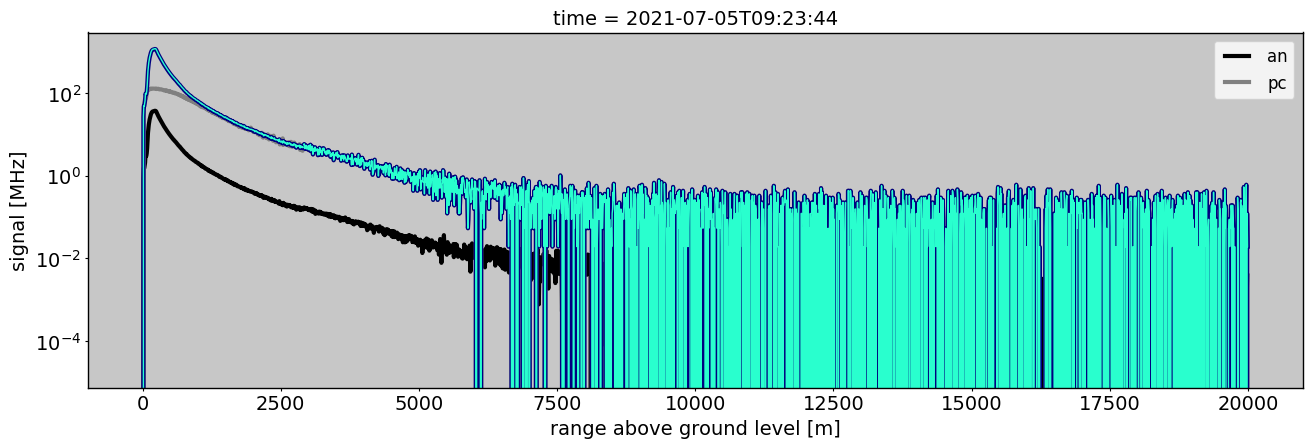

In [15]:
fig,ax = plt.subplots(figsize=[15,5])
signal_an.plot(ax=ax, lw=3, c='k', label='an')
signal_pc.plot(ax=ax, lw=3, c='grey', label='pc')
ax.plot(z,signal_gl[0,:], c= colors[0], lw=3)
ax.plot(z,signal_gl[2,:], c= colors[2], lw=1)
ax.set_yscale('log')
# ax.set_ylim(1,3000)
# ax.set_xlim(0,2000)
ax.legend()

In [16]:
residuo_gl

array([10,  7,  4,  2,  0,  0])

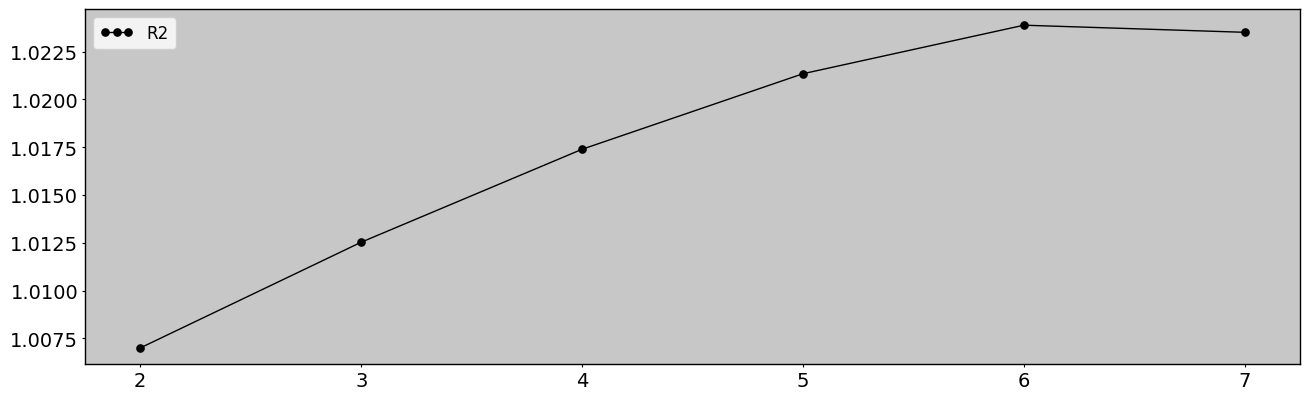

In [8]:
# slope_pc, intercept_pc, r2_pc = moving_linear_fit_2D(z, n_corrected_array, w=gluing_window, get_intercept=True)
# slope_an, intercept_an, r2_an = moving_linear_fit(z, nsignal_an, w=gluing_window, get_intercept=True)



#Cost function
residuo_gl = residuals_2D(n_corrected_array, gluing_tests, axis=0)



In [65]:
# Gluing
for idx, tau_ in enumerate(tau_range):
    gl_pp[idx], _, gluing_height = gluing(nsignal_an, n_corrected_array[idx,:], range_min=gluing_range[0], range_max=gluing_range[1])


AttributeError: 'numpy.ndarray' object has no attribute 'sel'

(0.0, 3000.0)

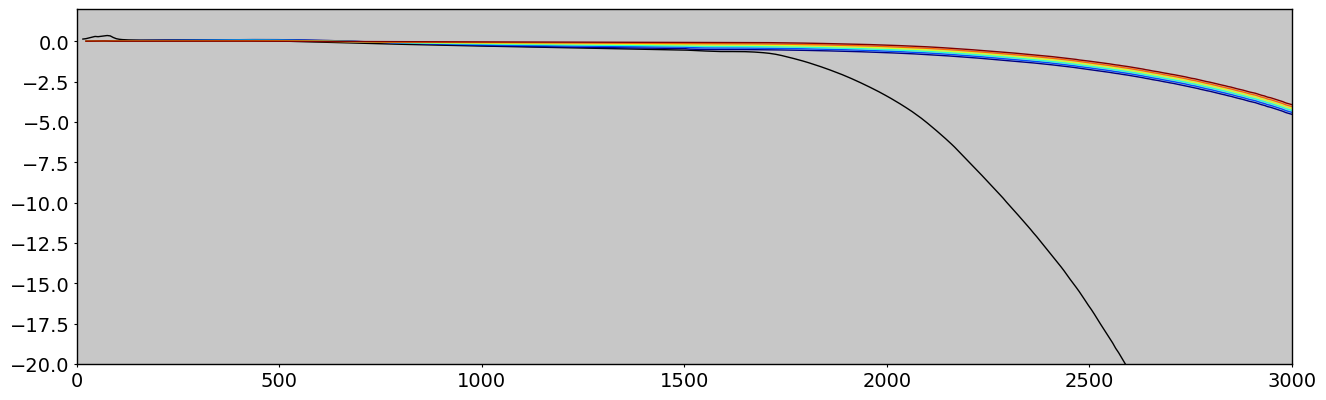

In [247]:
fig,ax = plt.subplots(figsize=[15,5])
ax.plot(z,slope_an, c= 'k')
for idx, tau_ in enumerate(tau_range):    
    ax.plot(z,slope_pc[idx,:], c= colors[idx])
# ax.set_yscale('log')
ax.set_ylim(-20,2)
ax.set_xlim(0,3000)

(1500.0, 3500.0)

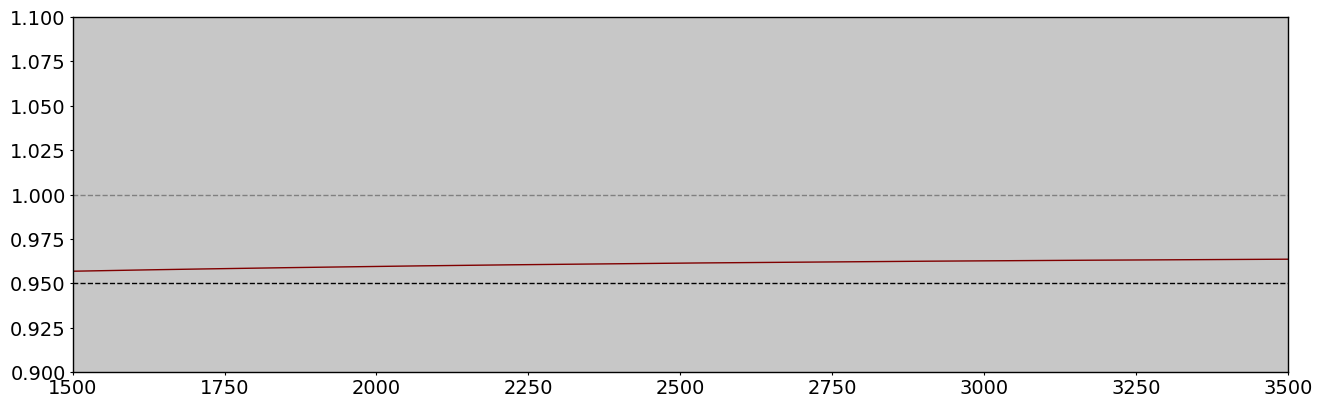

In [60]:
fig,ax = plt.subplots(figsize=[15,5])
for idx, tau_ in enumerate(tau_range):    
    ax.plot(z,r2_fit[idx,:], c= colors[idx])
# ax.set_yscale('log')
plt.hlines(1, xmin=0,xmax=10000, color='grey', ls='--')
plt.hlines(0.95, xmin=0,xmax=10000, color='k', ls='--')
ax.set_ylim(0.90,1.1)
ax.set_xlim(1500,3500)

In [40]:
gluing_good = r2_fit > 0.975    

In [43]:
gluings = np.zeros(gluing_good.shape[1], dtype=bool)
for idx in np.arange(len(gluings)):
    gluings[idx] = gluing_good[:,idx].all()

In [59]:
gluings = np.zeros(gluing_good.shape[1], dtype=bool)
gluings = np.array([gluing_good[:,idx].all() for idx in np.arange(len(gluings))], dtype=bool)

z[gluings][np.ceil(len(z[gluings])/2).astype(int)]


2685.0

In [57]:
np.ceil(len(gluings)/2).astype(int)

1333

In [13]:
gluing_bin = np.where(r2_fit > 0.9)[0][-1]
gluing_window = 10 
gluing_window = np.asarray([gluing_bin-gluing_window, gluing_bin+gluing_window])
gluing_window*3.75

array([1867.5, 1942.5])

In [184]:
channel_an, channel_pc = '355xta', '355xtp'
signal_an = lidar[f'signal_{channel_an}'].sel(time=time_).values
signal_pc = lidar[f'signal_{channel_pc}'].sel(time=time_).values
# signal_pc_with_constant = add_constant(signal_pc)
rols = RollingOLS(signal_an, signal_pc, window=60)
rres = rols.fit()
params = rres.params


In [73]:
slope, intercept, r2 = moving_linear_fit(signal_an, signal_pc, w= 30, get_intercept=True)

(0.0, 2000.0)

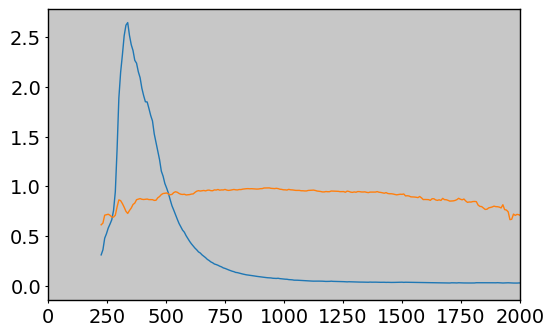

In [78]:
#ploting
plt.plot(z,slope)
plt.plot(z, r2)
plt.xlim(0,2000)

(0.0, 5000.0)

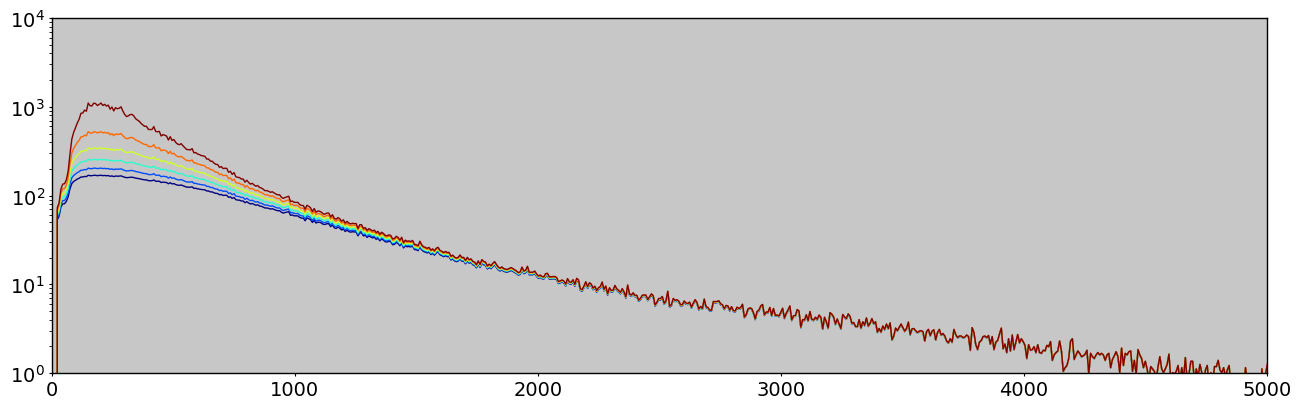

In [164]:
tau_range = np.arange(2, 8.0,1)
colors = color_list(len(tau_range))
corrected_array = np.ones((len(tau_range), len(signal_pc)))*np.nan
fig,ax = plt.subplots(figsize=[15,5])
for idx, tau_ in enumerate(tau_range):
    corrected_array[idx,:] = signal_pc / (1 - signal_pc * tau_ * 1e-3)    
    ax.plot(z,corrected_array[idx,:], c= colors[idx])

ax.set_ylim(1,1e4)
ax.set_yscale('log')
ax.set_xlim(0,5000)

(0.0, 5000.0)

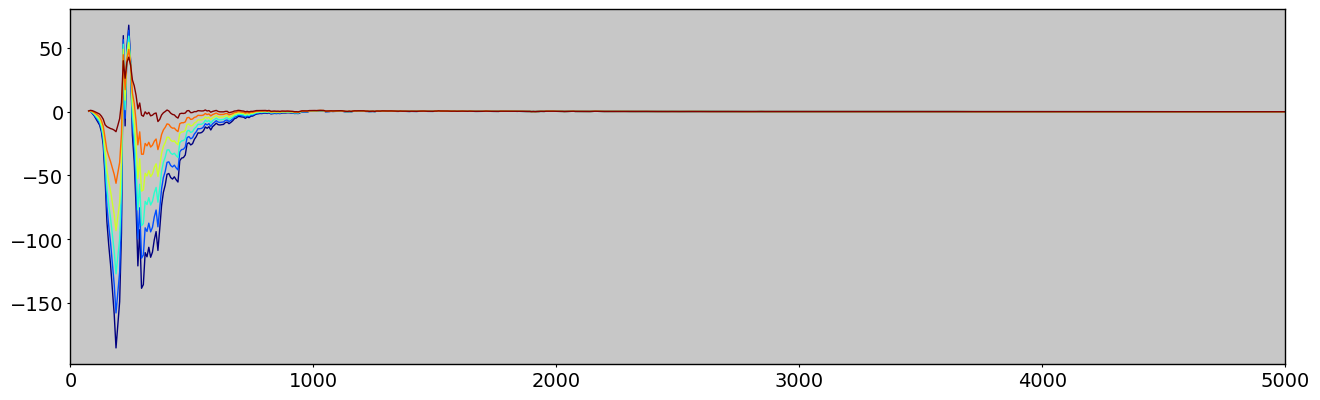

In [158]:
colors = color_list(len(tau_range))
fig,ax = plt.subplots(figsize=[15,5])
for idx, tau_ in enumerate(tau_range):
    ax.plot(z,predicted_pc[idx,:], c= colors[idx])

# ax.set_ylim(1,1e4)
# ax.set_yscale('log')
ax.set_xlim(0,5000)

In [100]:
corrected_array[0,:]

array([ 0.00000000e+00,  0.00000000e+00,  5.31956264e+01, ...,
       -4.89445097e-02,  1.21148071e-01,  1.90785654e-02])

ValueError: zero-size array to reduction operation maximum which has no identity

In [9]:
corrected_array[tau_, :] = corrected_

IndexError: index 19 is out of bounds for axis 0 with size 18

In [23]:
slope, intercept = window_lin_reg(signal_an, signal_pc, 100)

In [25]:
slope, intercept

(array([ 1.55168345,  1.46473961,  1.38180691, ..., 18.68669827,
        18.81947888, 17.7232209 ]),
 array([ 8.11643415e+01,  8.31428520e+01,  8.50777308e+01, ...,
        -1.26846745e-02, -1.20406598e-02, -7.36041668e-03]))

In [19]:
def coarse_tau_finder(signal_an, signal_pc, tau_range, gluing_range):
    gluing_window = int(gluing_range/3.75)
    ranges = signal_an.range.values
    gluing_height = np.mean(gluing_range)
    residuo_gl = np.ones(len(tau_range))*np.nan

    corrected_pc = signal_pc / (1 - signal_pc * tau_ * 1e-3)
    
    slope, intercept, r2 = moving_linear_fit_2D(signal_an, corrected_array, w=gluing_window, get_intercept=True)

    
    #An to be glued
    glue_signal_an = signal_an.sel(range=slice(*gluing_range))
    
    #Cálculo de residuos
    for idx_tau, tau_ in enumerate(tau_range):        
        corrected_pc_ = signal_pc / (1 - signal_pc * tau_ * 1e-3)
        #An to be glued
        corrected_pc2glue_ = corrected_pc_.sel(range=slice(*gluing_range))        

        #Gluing coefficients        
        fit_values_ = np.polyfit(glue_signal_an, corrected_pc2glue_,1)
                
        #Gluing signal merge
        an2pc_ = np.polyval(fit_values_,signal_an)
        signal_gl_ = np.ones(len(ranges))*np.nan
        signal_gl_[ranges<gluing_height] = an2pc_[ranges<gluing_height] 
        signal_gl_[ranges>gluing_height] = corrected_pc_[ranges>gluing_height]
        residuo_gl[idx_tau] = residuals(corrected_pc_, signal_gl_)

    # Minimum 
        tau_min = tau_range[np.nanargmin(residuo_gl)]
    return tau_min

In [17]:

tau_range = np.arange(2,20,2) # rangos establecido según código final_investigación

time_range = ('2021-07-05T09:23:44.000000000', '2021-07-05T09:24:43.000000000')
gluing_range = np.asarray((1250,1500))
gluing_height = np.mean(gluing_range)
slidar = lidar.sel(time=slice(*time_range))
ranges = slidar.range.values

dict_pc = {}
residuos = {}
signal_gl = {}
residuo_gl = np.ones(len(tau_range))*np.nan
corrected_r = np.ones(len(tau_range))*np.nan
optimals_taus = np.ones(len(slidar.time))*np.nan

tau_min_list = []
for idx_time, time_ in enumerate(slidar.time):
    signal_an = slidar[f'signal_{channel_an}'].sel(time=time_)
    signal_pc = slidar[f'signal_{channel_pc}'].sel(time=time_)
    #coarse tau finder
    tau_min_ = coarse_tau_finder(signal_an.values, signal_pc.values, ranges, tau_range, gluing_range)
    tau_min_list.append(tau_min_)


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1mNo implementation of function Function(<function vstack at 0x000002027B4F72E0>) found for signature:
 
 >>> vstack(list(array(float64, 1d, C))<iv=None>)
 
There are 4 candidate implementations:
[1m  - Of which 4 did not match due to:
  Overload in function '_OverloadWrapper._build.<locals>.ol_generated': File: numba\core\overload_glue.py: Line 129.
    With argument(s): '(list(array(float64, 1d, C))<iv=None>)':[0m
[1m   Rejected as the implementation raised a specific error:
     TypeError: np.vstack(): expecting a non-empty tuple of arrays, got list(array(float64, 1d, C))<iv=None>[0m
  raised from c:\Users\Usuario\Documents\gitlab\gfatpy\.venv\lib\site-packages\numba\core\typing\npydecl.py:748
[0m
[0m[1mDuring: resolving callee type: Function(<function vstack at 0x000002027B4F72E0>)[0m
[0m[1mDuring: typing of call at C:\Users\Usuario\AppData\Local\Temp\ipykernel_26640\846143361.py (21)
[0m


In [16]:
channel_an, channel_pc = '355xta', '355xtp'
tau_range = np.arange(3,20,1) # rangos establecido según código final_investigación


time_range = ('2021-07-05T09:23:44.000000000', '2021-07-05T09:24:43.000000000')
gluing_range = (1250,1500)
gluing_height = np.mean(gluing_range)
slidar = lidar.sel(time=slice(*time_range))
ranges = slidar.range

dict_pc = {}
residuos = {}
signal_gl = {}
residuo_gl = np.ones(len(tau_range))*np.nan
corrected_r = np.ones(len(tau_range))*np.nan
optimals_taus = np.ones(len(slidar.time))*np.nan


for idx_time, time_ in enumerate(slidar.time):
    signal_an = slidar[f'signal_{channel_an}'].sel(time=time_)
    signal_pc = slidar[f'signal_{channel_pc}'].sel(time=time_)

    glue_signal_an = signal_an.sel(range=slice(*gluing_range))    
    
    #Cálculo de residuos
    for idx_tau, tau_ in enumerate(tau_range):        
        dict_pc[tau_] = signal_pc / (1 - signal_pc * tau_ * 1e-3)
        glue_dict_pc_ = dict_pc[tau_].sel(range=slice(*gluing_range))        
        corrected_r[idx_tau] = np.corrcoef(glue_signal_an, glue_dict_pc_)[0,1]

        #Gluing coefficients        
        fit_values_ = np.polyfit(glue_signal_an, glue_dict_pc_,1)
                
        #Gluing signal merge
        an2pc_ = np.polyval(fit_values_,signal_an)
        signal_gl_ = np.ones(len(ranges))*np.nan
        signal_gl_[ranges<gluing_height] = an2pc_[ranges<gluing_height] 
        signal_gl_[ranges>gluing_height] = dict_pc[tau_][ranges>gluing_height]        
        residuo_gl[idx_tau] = residuals(dict_pc[tau_], signal_gl_)

        #Ajuste de datos
        fit2 = np.polyfit(tau_range, residuo_gl, 2)

        tau_range_fine = np.arange(tau_range.min(),tau_range.max(),0.01)                
        #Cálculo optimal tau
        found_tau_index = np.polyval(fit2,tau_range_fine).argmin()
        optimals_taus[idx_time] = tau_range_fine[found_tau_index]

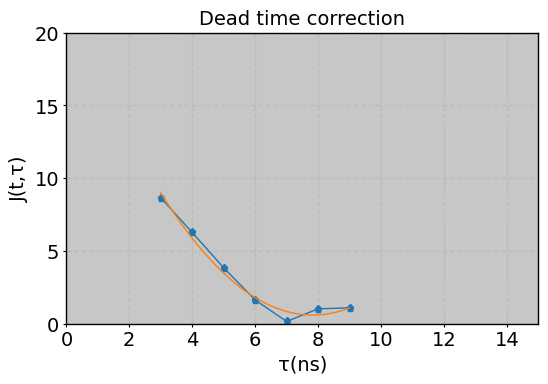

In [17]:
plt.plot(tau_range, residuo_gl, marker='p')
plt.plot(tau_range_fine, np.polyval(fit2,tau_range_fine)) #ajuste
plt.grid(linestyle='--')
plt.xlim(0,15)
plt.ylim(0,20)
plt.title('Dead time correction')
plt.xlabel('τ(ns)')
plt.ylabel('J(t,τ)') #residuo
plt.show()

In [10]:
optimals_taus

array([5.99, 5.99])

In [12]:
tau_range_fine

array([2.  , 2.01, 2.02, 2.03, 2.04, 2.05, 2.06, 2.07, 2.08, 2.09, 2.1 ,
       2.11, 2.12, 2.13, 2.14, 2.15, 2.16, 2.17, 2.18, 2.19, 2.2 , 2.21,
       2.22, 2.23, 2.24, 2.25, 2.26, 2.27, 2.28, 2.29, 2.3 , 2.31, 2.32,
       2.33, 2.34, 2.35, 2.36, 2.37, 2.38, 2.39, 2.4 , 2.41, 2.42, 2.43,
       2.44, 2.45, 2.46, 2.47, 2.48, 2.49, 2.5 , 2.51, 2.52, 2.53, 2.54,
       2.55, 2.56, 2.57, 2.58, 2.59, 2.6 , 2.61, 2.62, 2.63, 2.64, 2.65,
       2.66, 2.67, 2.68, 2.69, 2.7 , 2.71, 2.72, 2.73, 2.74, 2.75, 2.76,
       2.77, 2.78, 2.79, 2.8 , 2.81, 2.82, 2.83, 2.84, 2.85, 2.86, 2.87,
       2.88, 2.89, 2.9 , 2.91, 2.92, 2.93, 2.94, 2.95, 2.96, 2.97, 2.98,
       2.99, 3.  , 3.01, 3.02, 3.03, 3.04, 3.05, 3.06, 3.07, 3.08, 3.09,
       3.1 , 3.11, 3.12, 3.13, 3.14, 3.15, 3.16, 3.17, 3.18, 3.19, 3.2 ,
       3.21, 3.22, 3.23, 3.24, 3.25, 3.26, 3.27, 3.28, 3.29, 3.3 , 3.31,
       3.32, 3.33, 3.34, 3.35, 3.36, 3.37, 3.38, 3.39, 3.4 , 3.41, 3.42,
       3.43, 3.44, 3.45, 3.46, 3.47, 3.48, 3.49, 3.

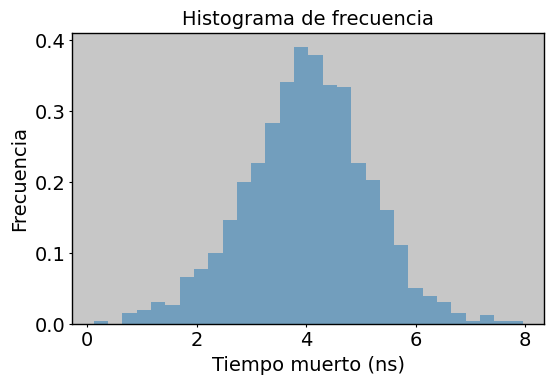

In [13]:
mu = np.mean(tau_range_fine)
sigma = np.std(tau_range_fine)
gaussian_samples = np.random.normal(mu, sigma, size=1000)

# Graficar el histograma de la distribución gaussiana
plt.hist(gaussian_samples, bins=30, density=True, alpha=0.5)
plt.xlabel('Tiempo muerto (ns)')
plt.ylabel('Frecuencia')
plt.title('Histograma de frecuencia')
plt.show()

In [ ]:
import multiprocessing as mp

# Define a function to process each time slice
def process_time_slice(time):
    signal_an = slidar[f'signal_{channel_an}'].sel(time=time)
    signal_pc = slidar[f'signal_{channel_pc}'].sel(time=time)
    glue_signal_an = signal_an.sel(range=slice(*gluing_range))

    # Cálculo de residuos
    for idx_tau, tau_ in enumerate(tau_range):
        # Rest of the code...

# Create a pool of worker processes
pool = mp.Pool()

# Iterate over each time slice and assign it to a worker process
results = []
for idx_time, time_ in enumerate(slidar.time):
    result = pool.apply_async(process_time_slice, args=(time_,))
    results.append(result)

# Wait for all worker processes to finish
pool.close()
pool.join()

# Get the results from the worker processes
for idx_time, result in enumerate(results):
    result.get()
